In [67]:
import os
import pandas as pd
import numpy as np

In [135]:
df = pd.read_csv("../data/raw/LendingClub/accepted_2007_to_2018Q4.csv", low_memory = False)

In [133]:
df[:200000].to_csv("../data/raw/LendingClub/proba.csv")

In [134]:
asd = pd.read_csv("../data/raw/LendingClub/proba.csv", low_memory = False)

In [81]:
def lendingclub_split_indices(
    df,
    train_size: int,
    val_size: int, 
    test_size: int, 
    seed: int
):

    date_col="issue_d"

    # ---------------------------------------------
    # ratio check
    # ---------------------------------------------
    total = (
        train_size
        + val_size
        + test_size
    )

    assert abs(total - 1.0) < 1e-6, \
        "Ratios must sum to 1"

    # ---------------------------------------------
    # copy
    # ---------------------------------------------
    temp_df = df.copy()

    # ---------------------------------------------
    # datetime conversion
    # ---------------------------------------------
    temp_df[date_col] = pd.to_datetime(
        temp_df[date_col],
        format="%b-%Y",
        errors="coerce"
    )

    # ---------------------------------------------
    # stable deterministic shuffle
    # ---------------------------------------------
    rng = np.random.default_rng(seed)

    temp_df["_rand"] = rng.random(len(temp_df))

    # ---------------------------------------------
    # sort by time
    # secondary sort: random
    # ---------------------------------------------
    temp_df = temp_df.sort_values(
        by=[date_col, "_rand"]
    )

    sorted_indices = temp_df.index.values

    # ---------------------------------------------
    # split positions
    # ---------------------------------------------
    n = len(sorted_indices)

    train_end = int(
        n * train_size
    )

    val_end = int(
        n * (train_size + val_size)
    )

    # ---------------------------------------------
    # splits
    # ---------------------------------------------
    train_idx = sorted_indices[:train_end]

    val_idx = sorted_indices[
        train_end:val_end
    ]

    test_idx = sorted_indices[val_end:]

    return train_idx, val_idx, test_idx


In [83]:
train_idx, val_idx, test_idx = lendingclub_split_indices(df, 0.8, 0.1, 0.1, 42)

In [84]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


class LendingClubPreprocessor:

    def __init__(self):

        # =================================================
        # categorical columns
        # =================================================
        self.cat_cols = [
            "grade",
            "sub_grade",
            "home_ownership",
            "verification_status",
            "purpose",
            "addr_state",
            "initial_list_status"
        ]

        # =================================================
        # skewed numerical columns
        # =================================================
        self.log_cols = [
            "annual_inc",
            "loan_amnt",
            "installment",
            "revol_bal"
        ]

        # =================================================
        # columns to remove
        # =================================================
        self.drop_cols = [

            # index
            "Unnamed: 0",

            # identifiers
            "id",
            "member_id",
            "url",

            # free text
            "desc",
            "title",
            "emp_title",

            # leakage
            "funded_amnt",
            "funded_amnt_inv",

            "out_prncp",
            "out_prncp_inv",

            "total_pymnt",
            "total_pymnt_inv",

            "total_rec_prncp",
            "total_rec_int",

            "recoveries",
            "collection_recovery_fee",

            "last_pymnt_d",
            "last_credit_pull_d",

            # hardship
            "hardship_flag",
            "hardship_type",
            "hardship_reason",
            "hardship_status",

            "hardship_start_date",
            "hardship_end_date",

            "hardship_amount",
            "hardship_length",

            "hardship_payoff_balance_amount",
            "hardship_last_payment_amount",

            # settlement
            "debt_settlement_flag",
            "debt_settlement_flag_date",

            "settlement_status",
            "settlement_date",

            "settlement_amount",
            "settlement_percentage",
            "settlement_term",
        ]

        self.num_cols = None

        self.scaler = StandardScaler()

        self.label_encoders = {
            col: LabelEncoder()
            for col in self.cat_cols
        }

        self.num_feature_count = 0
        self.cat_feature_count = 0

        self.fitted = False

    # =====================================================
    # CLEAN DATAFRAME
    # =====================================================

    def _clean_dataframe(self, df):

        df = df.copy()

        # -------------------------------------------------
        # keep only binary target rows
        # -------------------------------------------------
        df = df[
            df["loan_status"].isin([
                "Fully Paid",
                "Charged Off"
            ])
        ]

        # -------------------------------------------------
        # int_rate
        # "13.56%" -> 13.56
        # -------------------------------------------------
        if "int_rate" in df.columns:

            df["int_rate"] = (
                df["int_rate"]
                .astype(str)
                .str.replace("%", "", regex=False)
            )

            df["int_rate"] = pd.to_numeric(
                df["int_rate"],
                errors="coerce"
            )

        # -------------------------------------------------
        # term
        # "36 months" -> 36
        # -------------------------------------------------
        if "term" in df.columns:

            extracted = (
                df["term"]
                .astype(str)
                .str.extract(r"(\d+)")
            )

            df["term"] = pd.to_numeric(
                extracted[0],
                errors="coerce"
            )

        # -------------------------------------------------
        # emp_length
        # "10+ years" -> 10
        # -------------------------------------------------
        if "emp_length" in df.columns:

            extracted = (
                df["emp_length"]
                .astype(str)
                .str.extract(r"(\d+)")
            )

            df["emp_length"] = pd.to_numeric(
                extracted[0],
                errors="coerce"
            )

        # -------------------------------------------------
        # date columns
        # -------------------------------------------------
        date_cols = [
            "issue_d",
            "earliest_cr_line"
        ]

        for col in date_cols:

            if col in df.columns:

                dt = pd.to_datetime(
                    df[col],
                    format="%b-%Y",
                    errors="coerce"
                )

                df[col] = (
                    (dt - pd.Timestamp("1970-01-01"))
                    .dt.days
                )

        # -------------------------------------------------
        # remove fully empty columns
        # -------------------------------------------------
        df = df.dropna(
            axis=1,
            how="all"
        )

        # -------------------------------------------------
        # remove selected columns
        # -------------------------------------------------
        existing_drop_cols = [
            c for c in self.drop_cols
            if c in df.columns
        ]

        df = df.drop(
            columns=existing_drop_cols,
            errors="ignore"
        )

        return df

    # =====================================================
    # FIT
    # =====================================================

    def fit(self, df):

        df = self._clean_dataframe(df)

        # -------------------------------------------------
        # numerical columns
        # -------------------------------------------------
        self.num_cols = [
            c for c in df.columns
            if c not in self.cat_cols
            and c != "loan_status"
        ]

        # -------------------------------------------------
        # categorical encoders
        # -------------------------------------------------
        for col in self.cat_cols:

            if col not in df.columns:
                continue

            vals = (
                df[col]
                .fillna("UNK")
                .astype(str)
            )

            unique_vals = vals.unique().tolist()

            if "UNK" not in unique_vals:
                unique_vals.append("UNK")

            self.label_encoders[col].fit(
                unique_vals
            )

        # -------------------------------------------------
        # numerical dataframe
        # -------------------------------------------------
        num_df = df[self.num_cols].copy()

        # convert to numeric
        for col in num_df.columns:

            num_df[col] = pd.to_numeric(
                num_df[col],
                errors="coerce"
            )

        # fill NaN
        num_df = num_df.fillna(
            num_df.median()
        )

        # -------------------------------------------------
        # log transform skewed columns
        # -------------------------------------------------
        for col in self.log_cols:

            if col in num_df.columns:

                num_df[col] = np.log1p(
                    np.maximum(num_df[col], 0)
                )

        # -------------------------------------------------
        # fix inf / overflow
        # -------------------------------------------------
        num_df = num_df.replace(
            [np.inf, -np.inf],
            np.nan
        )

        num_df = num_df.clip(
            lower=-1e10,
            upper=1e10
        )

        num_df = num_df.fillna(
            num_df.median()
        )

        # -------------------------------------------------
        # scaler fit
        # -------------------------------------------------
        self.scaler.fit(
            num_df.values
        )

        self.num_feature_count = len(self.num_cols)
        self.cat_feature_count = len(self.cat_cols)

        self.fitted = True

    # =====================================================
    # TRANSFORM
    # =====================================================

    def transform(self, df):

        assert self.fitted, "Call fit first"
    

        # -----------------------------------------
        # clean rows
        # -----------------------------------------
        df = self._clean_dataframe(df)
    
        # -----------------------------------------
        # target
        # -----------------------------------------
        y = None
    
        if "loan_status" in df.columns:
    
            y = (
                df["loan_status"] == "Charged Off"
            ).astype(np.float32).values
    
            df = df.drop(
                columns=["loan_status"],
                errors="ignore"
            )
            
        # -------------------------------------------------
        # categorical features
        # -------------------------------------------------
        cat_features = []

        for col in self.cat_cols:

            if col not in df.columns:
                continue

            vals = (
                df[col]
                .fillna("UNK")
                .astype(str)
            )

            le = self.label_encoders[col]

            vals = vals.map(
                lambda x:
                x if x in le.classes_
                else "UNK"
            )

            encoded = le.transform(vals)

            cat_features.append(
                encoded.reshape(-1, 1)
            )

        cat_features = np.concatenate(
            cat_features,
            axis=1
        )

        # -------------------------------------------------
        # numerical features
        # -------------------------------------------------
        num_df = df[self.num_cols].copy()

        for col in num_df.columns:

            num_df[col] = pd.to_numeric(
                num_df[col],
                errors="coerce"
            )

        num_df = num_df.fillna(
            num_df.median()
        )

        # -------------------------------------------------
        # log transform
        # -------------------------------------------------
        for col in self.log_cols:

            if col in num_df.columns:

                num_df[col] = np.log1p(
                    np.maximum(num_df[col], 0)
                )

        # -------------------------------------------------
        # fix inf / overflow
        # -------------------------------------------------
        num_df = num_df.replace(
            [np.inf, -np.inf],
            np.nan
        )

        num_df = num_df.clip(
            lower=-1e10,
            upper=1e10
        )

        num_df = num_df.fillna(
            num_df.median()
        )

        # -------------------------------------------------
        # scale
        # -------------------------------------------------
        num_features = self.scaler.transform(
            num_df.values
        )

        # -------------------------------------------------
        # concat
        # -------------------------------------------------
        X = np.concatenate(
            [num_features, cat_features],
            axis=1
        )

        return X.astype(np.float32), y

    # =====================================================
    # EMBEDDING INFO
    # =====================================================

    def get_embedding_info(self):

        info = {}

        for col in self.cat_cols:

            le = self.label_encoders[col]

            cardinality = len(le.classes_)

            emb_dim = min(
                50,
                (cardinality // 2) + 1
            )

            info[col] = {
                "cardinality": cardinality,
                "embedding_dim": emb_dim
            }

        return info

In [88]:
train_df = df.iloc[train_idx]

In [89]:
preprocessor = LendingClubPreprocessor()

In [90]:
preprocessor.fit(train_df)

/opt/conda/lib/python3.11/site-packages/sklearn/utils/extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/conda/lib/python3.11/site-packages/sklearn/utils/extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/opt/conda/lib/python3.11/site-packages/sklearn/utils/extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [91]:
X_all, y_all = preprocessor.transform(df)

In [100]:
clean_df = preprocessor._clean_dataframe(
    df
)

In [103]:
train_idx, val_idx, test_idx = lendingclub_split_indices(
        clean_df,
        train_size=0.7,
        val_size=0.1,
        test_size=0.2,
        seed=42
    )

In [106]:
len(train_idx)+len(val_idx)+len(test_idx)

1345310

In [107]:
len(clean_df)

1345310

In [111]:
train_idx[0]

np.int64(1249794)

In [115]:
len(clean_df) < max(train_idx)

np.True_

In [116]:
max(train_idx)

np.int64(2260697)

In [122]:
clean_df.index

Index([      0,       1,       2,       4,       5,       6,       7,       8,
             9,      12,
       ...
       2260677, 2260680, 2260684, 2260685, 2260686, 2260688, 2260690, 2260691,
       2260692, 2260697],
      dtype='int64', length=1345310)

In [123]:
train_idx

array([1249794,  631911,  711925, ..., 1255940,   40443, 1329578],
      shape=(941716,))

In [124]:
val_idx

array([2222843, 1040243, 1268847, ..., 2189835, 1269961,     569],
      shape=(134532,))

In [125]:
test_idx

array([ 384276, 1927530,  209958, ..., 1152280,  946415, 1734521],
      shape=(269062,))

In [128]:
clean_df.loc[train_idx]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,deferral_term,payment_plan_start_date,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,disbursement_method
1249794,16800.0,60,14.99,399.59,C,C5,10.0,MORTGAGE,44352.0,Source Verified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
631911,6400.0,36,17.09,228.47,D,D1,3.0,RENT,20000.0,Source Verified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
711925,21150.0,36,9.75,679.98,B,B3,NaN,OWN,74000.0,Not Verified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
403580,24375.0,60,19.99,645.66,E,E3,4.0,RENT,58100.0,Verified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
2221067,22000.0,60,22.74,616.91,E,E1,1.0,MORTGAGE,62000.0,Verified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1905353,6000.0,36,13.11,202.49,B,B4,10.0,RENT,26000.0,Not Verified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
1500175,15000.0,36,7.46,466.32,A,A4,2.0,RENT,59960.0,Not Verified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
1255940,13000.0,36,12.99,437.96,C,C1,9.0,MORTGAGE,45827.0,Not Verified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
40443,6000.0,36,12.59,200.99,C,C2,9.0,MORTGAGE,90000.0,Source Verified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash


In [130]:
y_all.long()

AttributeError: 'numpy.ndarray' object has no attribute 'long'

TypeError: imsave() missing 1 required positional argument: 'arr'

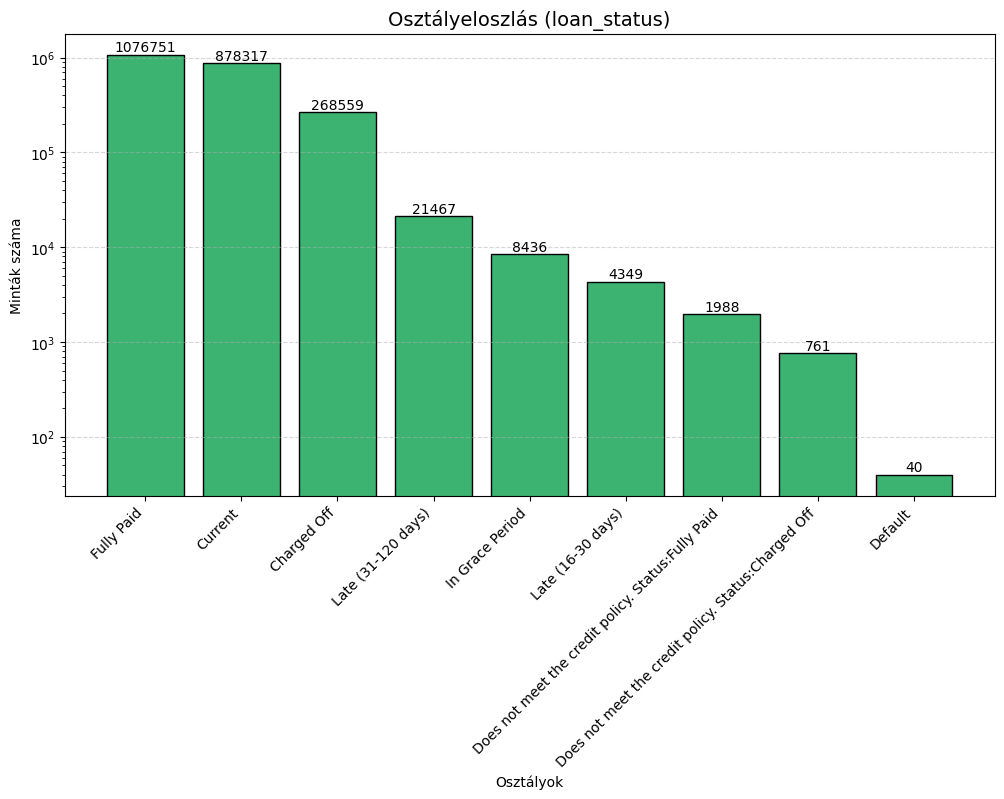

In [145]:
import matplotlib.pyplot as plt

counts = df["loan_status"].value_counts()

plt.figure(figsize=(12, 6))

bars = plt.bar(
    counts.index.astype(str),
    counts.values,
    color="mediumseagreen",
    edgecolor="black"
)

# cím
plt.title("Osztályeloszlás (loan_status)", fontsize=14)

# tengelyek
plt.xlabel("Osztályok")
plt.ylabel("Minták száma")

# értékek kiírása a sávokra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# rács (mint a képen)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.yscale("log")
# x tengely feliratok forgatása
plt.xticks(rotation=45, ha="right")
plt.imsave("lendingclub_num_class.png")


TypeError: Image data of dtype <U25 cannot be converted to float

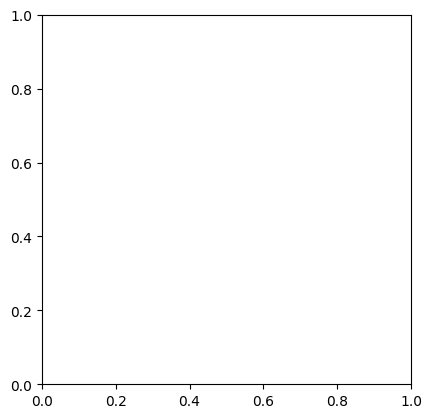